In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
plt.rcParams.update({
    # Figure & Resolution
    'figure.figsize': (3, 1.5),      # Standard rectangular size
    'figure.dpi': 100,             # High resolution for saving
    'savefig.dpi': 300,            # High resolution for exported images
    'savefig.bbox': 'tight',       # Removes unnecessary white space around the plot
    
    # Fonts & Text
    'font.family': 'sans-serif',   # Use serif for traditional journals, sans-serif for modern
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,               # Base font size
    'axes.titlesize': 10,          # Title size
    'axes.labelsize': 10,          # X and Y label size
    'xtick.labelsize': 10,         # Tick label size
    'ytick.labelsize': 10,         # Tick label size
    'legend.fontsize': 10,         # Legend text size
    
    # Axes & Spines (The "Clean" Look)
    'axes.spines.top': False,      # Remove top bounding box line
    'axes.spines.right': False,    # Remove right bounding box line
    'axes.linewidth': 1.1,         # Slightly thicker axes lines
    'axes.grid': False,            # Default to no grid (turn on manually if needed)
    
    # Ticks
    'xtick.direction': 'in',       # Ticks point inward
    'ytick.direction': 'in',       # Ticks point inward
    'xtick.major.size': 6,         # Major tick length
    'xtick.major.width': 1.2,      # Major tick thickness
    'ytick.major.size': 6,         # Major tick length
    'ytick.major.width': 1.2,      # Major tick thickness
    
    # Lines & Markers
    'lines.linewidth': 1.5,        # Thicker lines for visibility
    'lines.markersize': 4,         # Standard marker size
    
    # Legend
    'legend.frameon': False,       # Remove the box around the legend
    'legend.loc': 'best'           # Automatically place legend out of the way
})

## In this notebook we will
1. Learn the distinction between a real and analytic signal.
2. Create a dummy **bandlimited** signal .
3. Downsample the signal to see aliasing in action.
4. See how aliasing introduces corruption in real-life.

### Analytical vs Real signals
#### Goal: Create an analytical signal and verify that Real part of Analytical signal lines up with original signal

Fourier transform of a real signal is **hermitian symmetric**, which means that $F(-\nu)^* = F(\nu)$. In signal processing, it is often easier to deal with a complex signal rather than a real one, but signals that we process are real. The usual intuition dictates that we can do all processing to a complex signal and simply "take the real part at the end." This complex signal is known as the Analytic signal. Let's form one.

x type: float64 x2 type: complex128


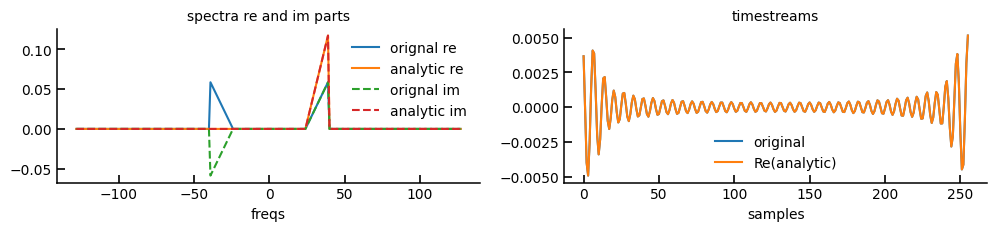

In [24]:
#generate some spectra

N = 256
X = np.zeros(N//2+1,dtype='complex128')
Xc = np.zeros(N,dtype='complex128') #analytic
k0 = 32
dk = 8
triangle = np.arange(0,2*dk)/N + 1j*np.arange(0,2*dk)/N #triangular real and imag parts (not-symmetric)

X[k0-dk:k0+dk]=triangle 
x=np.fft.irfft(X) #note irfft. -ve freqs will be conjugate of +ve freqs.  generates a real signal


Xc[k0-dk:k0+dk]=2*triangle # ignore -ve freqs and double +ve freqs
x2=np.fft.ifft(Xc) #note ifft.  generates a complex signal

freqs = np.fft.fftshift(np.fft.fftfreq(N))*N
# print(freqs)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x).real),label='orignal re' )
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).real),label='analytic re' )
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x).imag),label='orignal im' ,ls='dashed')
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).imag),label='analytic im' ,ls='dashed')
# plt.plot(freqs,np.fft.fftshift(np.fft.fft(x).imag),label='orignal im' )
# plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).imag),label='analytic im' )
plt.xlabel("freqs")
plt.title("spectra re and im parts")
plt.legend()
plt.subplot(122)
plt.title("timestreams")
plt.plot(x,label='original')
plt.plot(x2.real,label='Re(analytic)')
plt.xlabel("samples")
plt.legend()

print("x type:", x.dtype, "x2 type:", x2.dtype)

We note that the spectrum of the real, original signal is hermitian symmetric about 0, while that of the analytic signal is not hermitian symmetric. Let us now examine the analytical spectrum in more detail.

two-sided bandwidth is 16 channels.


(24.0, 40.0)

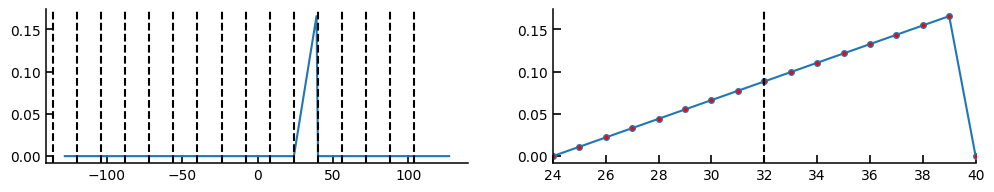

In [25]:
bw=2*dk
print("two-sided bandwidth is", bw, "channels.")
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.plot(freqs,np.fft.fftshift(np.abs(np.fft.fft(x2))),label='analytic re' )
for i in freqs:
    if i%bw==0: 
        plt.axvline(i-bw//2,ls='dashed',c='black')
plt.subplot(122)
plt.plot(freqs,np.fft.fftshift(np.abs(np.fft.fft(x2))),label='analytic re',marker='o',markerfacecolor='red')
plt.axvline(32,ls='dashed',c='black')
plt.axvline(48,ls='dashed',c='black')
plt.xlim(24,40)

### Downsample to see aliasing in action
#### Goal: Recover the triangle exactly

In the above example, I have intetionally kept the bandwidth of the signal an integer multiple of the FFT length **and** the center frequency as an exact integer at the exact center of the band. This means that the black lines span perfectly divide the Sampling bandwidth $f_s$ into 16 equal parts.

When we downsample the signal by a factor of 16, the new Sampling frequency is 1/16 of the original, or the width of one dashed section. The act of downsampling causes all the new, smaller, nyquist zones to overlap on top of each other.

Let's see what that looks like.

downsampling factor 16
length of downsampled signal 16


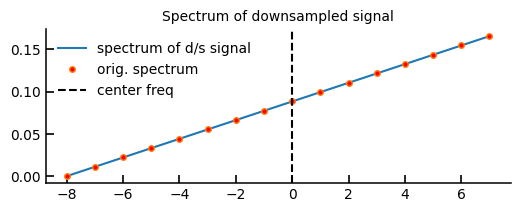

In [26]:
dsamp = N//bw
print("downsampling factor", dsamp)
x2_downsampled = x2[::dsamp]
downsampled_freqs = np.fft.fftshift(np.fft.fftfreq(len(x2_downsampled))) * len(x2_downsampled)
print("length of downsampled signal", len(x2_downsampled))
fig=plt.gcf()
fig.set_size_inches(6,2)
plt.title("Spectrum of downsampled signal")
plt.plot(downsampled_freqs, dsamp * np.fft.fftshift(np.abs(np.fft.fft(x2_downsampled))), label='spectrum of d/s signal')
plt.plot(downsampled_freqs, np.abs(2*triangle), ls='',marker='o',markerfacecolor='red', label='orig. spectrum')
plt.axvline(0,ls='--',c='black',label='center freq')
plt.legend()

We got our triangle of length 16 back! There's a scaling factor because of Numpy's IFFT convention but that's irrelevant for the demonstration. Since a DFT is inherently circulant, we can also visualize the overlapping of Nyquist zones on a circle. It's clumsy to do it in practice, but good for demonstration.

#### For visualization only

16


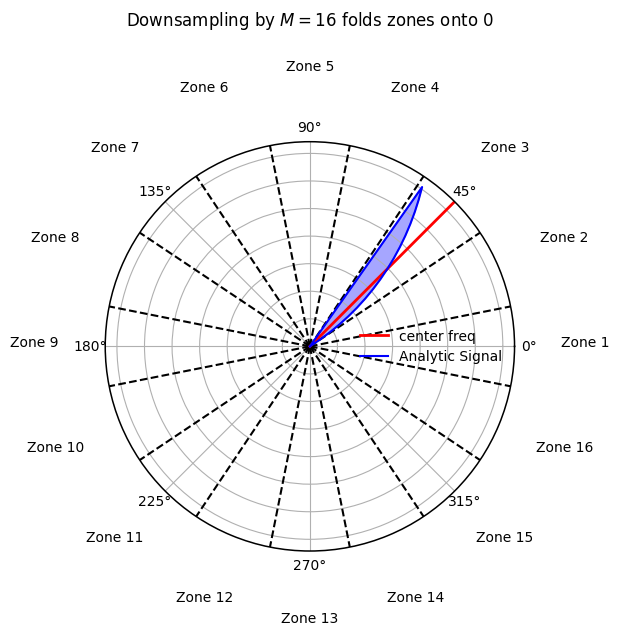

In [6]:
M = N//bw
print(M)

# Theta represents the frequency bin mapped to 0 -> 2pi
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
fig = plt.figure(figsize=(6,6),constrained_layout=True)
fig.suptitle(f"Downsampling by $M={M}$ folds zones onto 0", va='bottom')
ax = fig.add_subplot(111, projection='polar')
#Plot the "Nyquist Zones"
for i in range(M):
    zone_start = (i-0.5) * (2*np.pi / M)
    ax.axvline(zone_start, color='black', ls='--')
    # Label the zones
    ax.text(zone_start + np.pi/M, 0.25, f"Zone {i+1}", horizontalalignment='center')
ax.axvline(2* np.pi * k0 / N, color='black', lw=2, c='red',label='center freq')
#Plot the Analytic Signal
ax.plot(theta, np.abs(np.fft.fft(x2)), label='Analytic Signal', color='blue')
ax.fill(theta, np.abs(np.fft.fft(x2)), alpha=0.35, color='blue')
ax.set_yticklabels([])
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
plt.legend()
plt.show()

#### Exercise: What would happen if we were to downsample the original, real signal?

Use the same downsampling factor `dsamp`, but now downsample `x`

two-sided bandwidth is 16 channels.


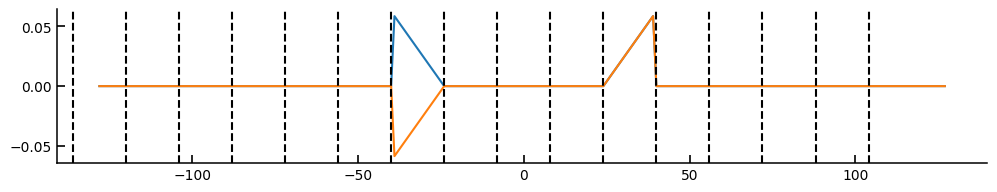

In [29]:
bw=2*dk
print("two-sided bandwidth is", bw, "channels.")
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.plot(freqs,np.fft.fftshift(np.real(np.fft.fft(x))),label='orig signal re' )
plt.plot(freqs,np.fft.fftshift(np.imag(np.fft.fft(x))),label='orig signal im' )
for i in freqs:
    if i%bw==0: 
        plt.axvline(i-bw//2,ls='dashed',c='black')

In [35]:
print("downsampling factor", dsamp)
x_downsampled =  # FILL IN
fig=plt.gcf()
fig.set_size_inches(6,2)
plt.title("Spectrum of downsampled signal")
plt.plot(np.fft.fftshift(np.fft.fft(x_downsampled).real),label='re')
plt.plot(np.fft.fftshift(np.fft.fft(x_downsampled).imag),label='im')
plt.xlim(1,bw)

SyntaxError: invalid syntax (2905383793.py, line 2)

### Effects of aliasing due to downsampling in real life

What if I now add some crap around the edges that we don't want?

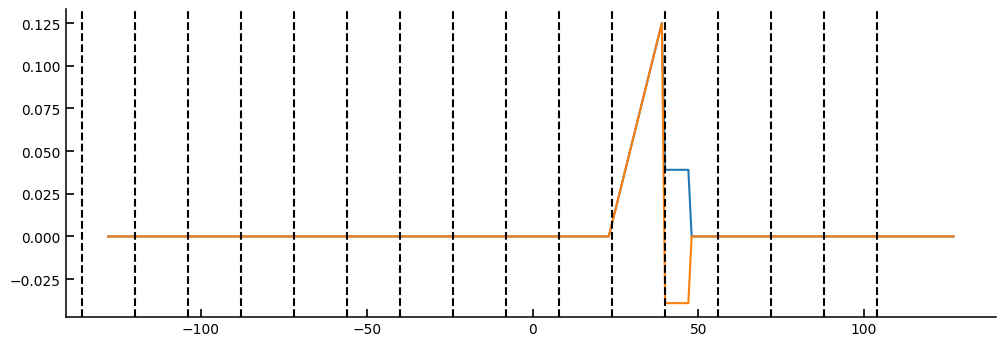

In [34]:
Xc = np.zeros(N,dtype='complex128') #analytic
Xc[k0-dk:k0+dk]=2*triangle
Xc[k0+dk:k0+dk+8]=10/N - 1j*10/N
x2=np.fft.ifft(Xc)
fig=plt.gcf()
fig.set_size_inches(12,4)
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).real),label='analytic re' )
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).imag),label='analytic re' )
for i in freqs:
    if i%bw==0: 
        plt.axvline(i-bw//2,ls='dashed',c='black')

We've added somee unintendent noise in one of the zones. What's going to happen? Remember that zones overlap. So after downsampling, we expect 8 channels at the left edge of the signal to get corruped. 

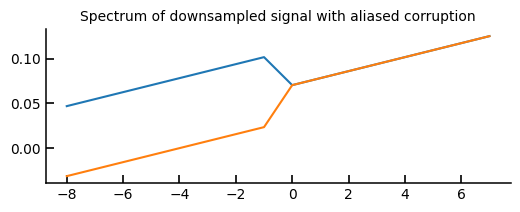

In [32]:
x2_downsampled = x2[::dsamp]
plt.title("Spectrum of downsampled signal with aliased corruption")
fig=plt.gcf()
fig.set_size_inches(6,2)
plt.plot(downsampled_freqs, dsamp * np.fft.fftshift(np.fft.fft(x2_downsampled).real), label='spectrum of d/s signal')
plt.plot(downsampled_freqs, dsamp * np.fft.fftshift(np.fft.fft(x2_downsampled).imag), label='spectrum of d/s signal')